In [7]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,BatchNormalization,Dropout,GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import MobileNetV2
# from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
# preprocessing_function=preprocess_input

In [8]:
train_dir = "few_shot_dataset/train"
val_dir = "few_shot_dataset/val"
test_dir = "few_shot_dataset/test"

In [10]:
IMG_SIZE = (224,224)
BATCH_SIZE = 4

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    fill_mode='nearest',      
    horizontal_flip=True,
    vertical_flip=False,
    shear_range=0.1,
    brightness_range=[0.8, 1.2],
    channel_shift_range=0.2,
)

val_datagen=ImageDataGenerator(rescale=1./255)
test_datagen=ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# =============================
# BASE MODEL (CNN)
# =============================
conv_base = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

conv_base.trainable = False

# =============================
# TRANSFORMER BLOCK ADDITION
# =============================
from tensorflow.keras.layers import (
    Dense, Dropout, GlobalAveragePooling1D,
    MultiHeadAttention, LayerNormalization, Add, Reshape, Input
)

inputs = Input(shape=(224,224,3))
x = conv_base(inputs)

# reshape feature map for attention
h, w, c = x.shape[1], x.shape[2], x.shape[3]
x = Reshape((h*w, c))(x)

# attention
attn = MultiHeadAttention(num_heads=4, key_dim=c)(x, x)

# match shapes using projection (IMPORTANT FIX)
x_proj = Dense(c)(x)
attn_proj = Dense(c)(attn)

x = Add()([x_proj, attn_proj])
x = LayerNormalization()(x)

# feed forward (KEEP SAME DIMENSION)
ff = Dense(c, activation='relu')(x)

x = Add()([x, ff])
x = LayerNormalization()(x)

# pooling
x = GlobalAveragePooling1D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.4)(x)

outputs = Dense(6, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

# =============================
# FINE TUNING (YOUR STYLE)
# =============================
conv_base.trainable = True
set_trainable = False

for layer in conv_base.layers:
    if layer.name == 'block_15_expand':
        set_trainable = True
    if set_trainable:
        layer.trainable = True
    else:
        layer.trainable = False

for layer in conv_base.layers:
    print(layer.name, layer.trainable)

Found 55 images belonging to 6 classes.
Found 33 images belonging to 6 classes.
Found 50 images belonging to 6 classes.
input_layer_4 False
Conv1 False
bn_Conv1 False
Conv1_relu False
expanded_conv_depthwise False
expanded_conv_depthwise_BN False
expanded_conv_depthwise_relu False
expanded_conv_project False
expanded_conv_project_BN False
block_1_expand False
block_1_expand_BN False
block_1_expand_relu False
block_1_pad False
block_1_depthwise False
block_1_depthwise_BN False
block_1_depthwise_relu False
block_1_project False
block_1_project_BN False
block_2_expand False
block_2_expand_BN False
block_2_expand_relu False
block_2_depthwise False
block_2_depthwise_BN False
block_2_depthwise_relu False
block_2_project False
block_2_project_BN False
block_2_add False
block_3_expand False
block_3_expand_BN False
block_3_expand_relu False
block_3_pad False
block_3_depthwise False
block_3_depthwise_BN False
block_3_depthwise_relu False
block_3_project False
block_3_project_BN False
block_4_exp

In [11]:
# Compile and train model:
# Optimizer:Adam

opt=tf.keras.optimizers.Adam(1e-5)


model.compile(optimizer=opt,loss=tf.keras.losses.categorical_crossentropy,metrics=['accuracy'])

In [12]:
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping,ReduceLROnPlateau
es=EarlyStopping(monitor='val_loss',patience=5,verbose=1)
reduce_lr=ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=3)

cb=[es,reduce_lr]

In [27]:

hist=model.fit(
    train_data,
    epochs=300,verbose=1,
    validation_data=val_data,
    callbacks=cb,
    shuffle=True
)

Epoch 1/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 712ms/step - accuracy: 1.0000 - loss: 0.0614 - val_accuracy: 0.8788 - val_loss: 0.3036 - learning_rate: 6.2500e-07
Epoch 2/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 687ms/step - accuracy: 0.9273 - loss: 0.3218 - val_accuracy: 0.8182 - val_loss: 0.3049 - learning_rate: 6.2500e-07
Epoch 3/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 682ms/step - accuracy: 0.9818 - loss: 0.1028 - val_accuracy: 0.8182 - val_loss: 0.3043 - learning_rate: 6.2500e-07
Epoch 4/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 687ms/step - accuracy: 0.9455 - loss: 0.1701 - val_accuracy: 0.8182 - val_loss: 0.2978 - learning_rate: 3.1250e-07
Epoch 5/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 683ms/step - accuracy: 0.9636 - loss: 0.1935 - val_accuracy: 0.8182 - val_loss: 0.2952 - learning_rate: 3.1250e-07
Epoch 5: early stopping


In [28]:
import matplotlib.pyplot as plt
import  numpy as np

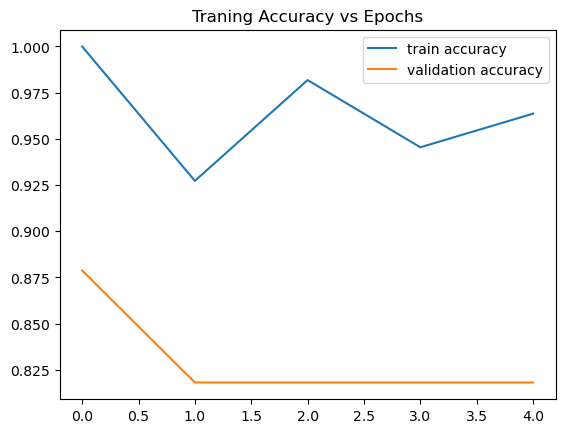

In [29]:
plt.title('Traning Accuracy vs Epochs')
plt.plot(hist.history['accuracy'],label='train accuracy')
plt.plot(hist.history['val_accuracy'],label='validation accuracy')
plt.legend()
plt.show()

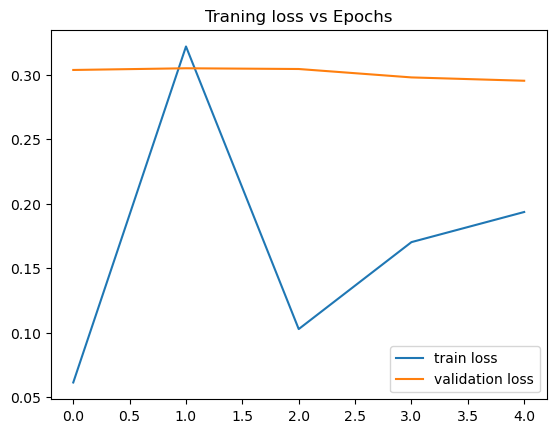

In [30]:
plt.title('Traning loss vs Epochs')
plt.plot(hist.history['loss'],label='train loss')
plt.plot(hist.history['val_loss'],label='validation loss')
plt.legend()
plt.show()

In [31]:
prediction=model.predict(test_data)

13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 184ms/step


In [32]:
y_pred = np.argmax(prediction, axis=1)
y_true=test_data.classes
print(len(y_true))
print(len(y_pred))

50
50


Test Accuracy:0.82
Test Precision:0.7987179487179489
Test Recall:0.7347883597883599
Test F1:0.7477880306827674


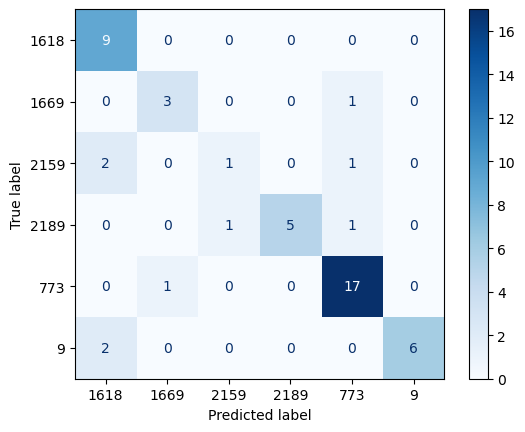

In [33]:
from sklearn.metrics import accuracy_score ,precision_score,recall_score,f1_score,confusion_matrix,ConfusionMatrixDisplay
acc=accuracy_score(y_true,y_pred)
pre=precision_score(y_true,y_pred,average='macro')
re=recall_score(y_true,y_pred,average='macro')
fs=f1_score(y_true,y_pred,average='macro')
cm=confusion_matrix(y_true,y_pred)
print(f'Test Accuracy:{acc}')
print(f'Test Precision:{pre}')
print(f'Test Recall:{re}')
print(f'Test F1:{fs}')
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=val_data.class_indices.keys())
disp.plot(cmap='Blues')
plt.show()